In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [3]:
from statsmodels.stats.anova import anova_lm

In [4]:
auto = load_data("Auto")
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


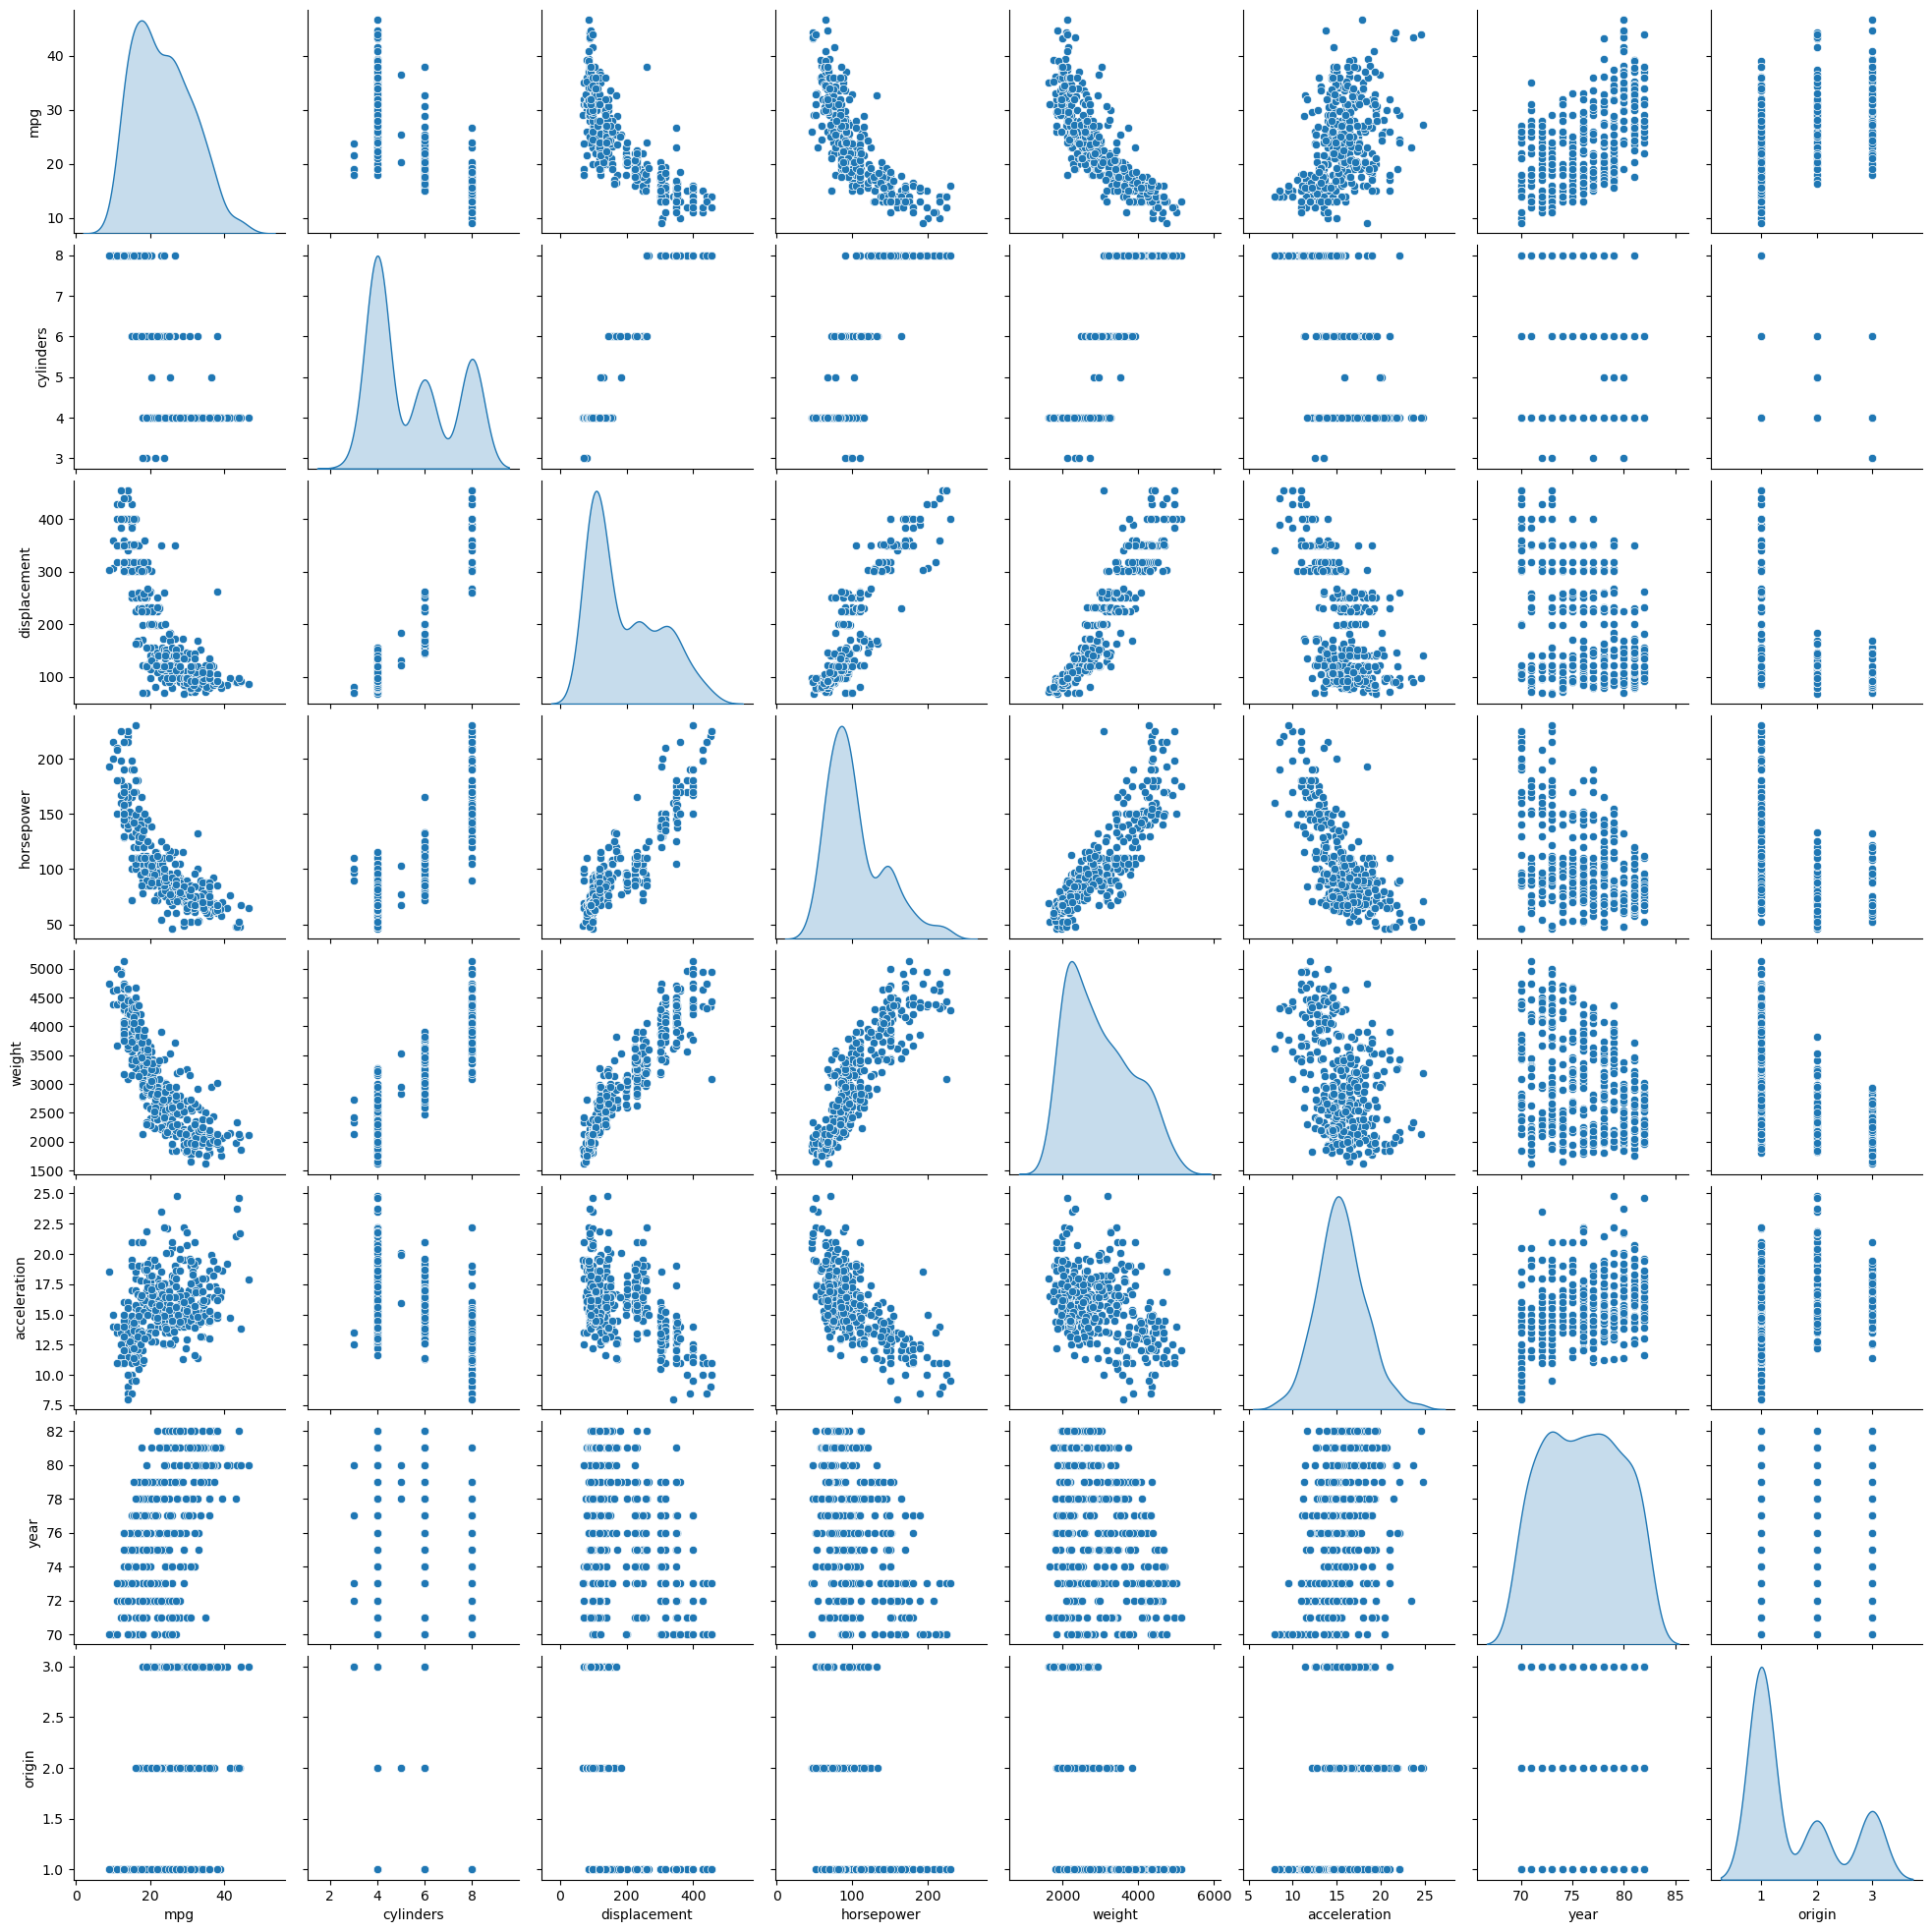

In [5]:
sns.pairplot(auto, diag_kind="kde")

In [6]:
auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [7]:
y = auto["mpg"].reset_index(drop=True)
y

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
387    27.0
388    44.0
389    32.0
390    28.0
391    31.0
Name: mpg, Length: 392, dtype: float64

In [8]:
predictors = auto.columns.drop(["mpg"])
predictors

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'year', 'origin'],
      dtype='object')

In [9]:
X = auto[predictors].reset_index(drop=True)
X

,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,8,307.0,130,3504,12.0,70,1
1,8,350.0,165,3693,11.5,70,1
2,8,318.0,150,3436,11.0,70,1
3,8,304.0,150,3433,12.0,70,1
4,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...
387,4,140.0,86,2790,15.6,82,1
388,4,97.0,52,2130,24.6,82,2
389,4,135.0,84,2295,11.6,82,1
390,4,120.0,79,2625,18.6,82,1


In [10]:
X["intercept"] = np.ones(auto.shape[0])

In [11]:
X

,cylinders,displacement,horsepower,weight,acceleration,year,origin,intercept
0,8,307.0,130,3504,12.0,70,1,1.0
1,8,350.0,165,3693,11.5,70,1,1.0
2,8,318.0,150,3436,11.0,70,1,1.0
3,8,304.0,150,3433,12.0,70,1,1.0
4,8,302.0,140,3449,10.5,70,1,1.0
...,...,...,...,...,...,...,...,...
387,4,140.0,86,2790,15.6,82,1,1.0
388,4,97.0,52,2130,24.6,82,2,1.0
389,4,135.0,84,2295,11.6,82,1,1.0
390,4,120.0,79,2625,18.6,82,1,1.0


In [12]:
model = sm.OLS(y, X)
results = model.fit()

In [13]:
summarize(results)

,coef,std err,t,P>|t|
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000
intercept,-17.2184,4.644,-3.707,0.000


In [14]:
predictors = auto.columns.drop('mpg')
predictors

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'year', 'origin'],
      dtype='object')

In [15]:
X = MS(predictors).fit_transform(auto).reset_index(drop=True)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


C (i), (ii) Yes there appears to be relationship between mpg with (displacement, weight, year, origin, intercept) but there is not enough evidence of any association of mpg with (cylinder, horsepower and acceleration)
  (iii) The coefficient of year variable suggest that for every year the mpg increases about 0.75, which is expected as the technology improves mpg get's better.

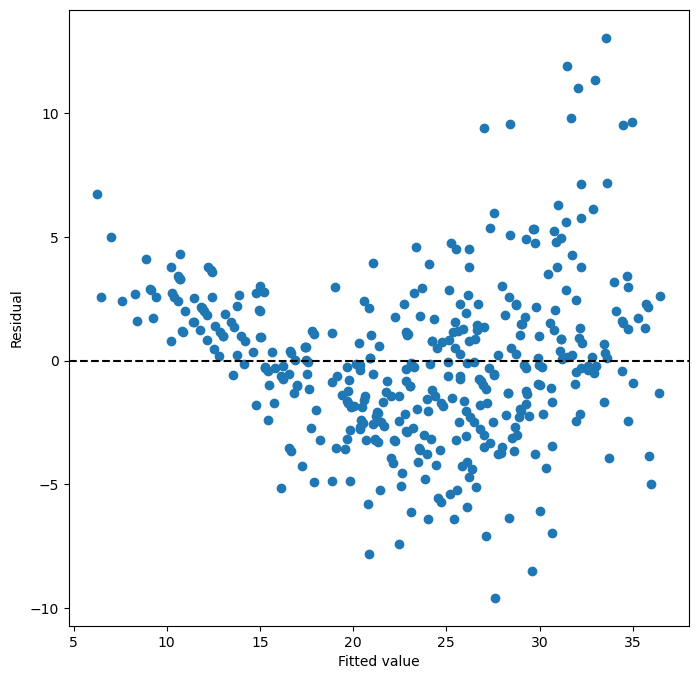

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel("Fitted value")
ax.set_ylabel("Residual")
ax.axhline(0, c='k', ls='--')

(d) The shows some evidence of non linearity, also the residual plot seems to point some outliers which have somewhat higher value of residual value compared to other points with same fitted value.

np.int64(13)

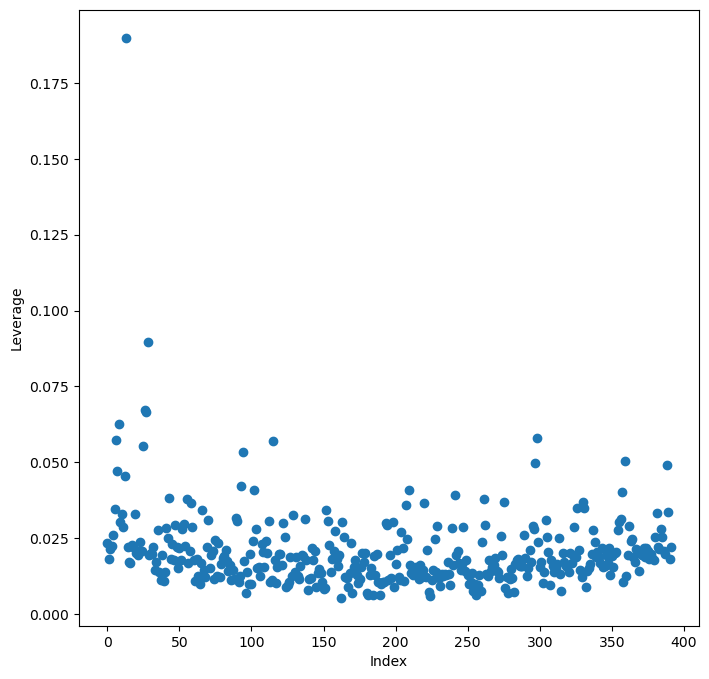

In [17]:
infl = results.get_influence()
ax = plt.subplots(figsize=(8, 8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel("Index")
ax.set_ylabel("Leverage")
np.argmax(infl.hat_matrix_diag)

Yes, the 13th observation has unusually high leverage all other observations has leverage < 0.100 while this observation has leverage of >0.175.

## Fitting Some Models with Interaction

In [18]:
# model containing weight, horsepower and their interaction.
X = MS(['weight', 'horsepower', ('weight', 'horsepower')]).fit_transform(auto).reset_index(drop=True)
model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,63.557900,2.343000,27.127,0.0
weight,-0.010800,0.001000,-13.921,0.0
horsepower,-0.250800,0.027000,-9.195,0.0
weight:horsepower,0.000054,0.000007,8.054,0.0


for the current model (containing weight, horsepowe, weight*horsepower ) we can see that the p value of interaction term is significant but still the coef is very small compared to actual terms coefficient so we can ignore it. In conclusion, the interaction term is not important here.

In [19]:
# model containing cylinder, weight and their interaction
X = MS(['cylinders', 'weight', ('cylinders', 'weight')]).fit_transform(auto).reset_index(drop=True)
model3 = sm.OLS(y, X)
summarize(model3.fit())

,coef,std err,t,P>|t|
intercept,65.3865,3.733,17.514,0.0
cylinders,-4.2098,0.724,-5.816,0.0
weight,-0.0128,0.001,-9.418,0.0
cylinders:weight,0.0011,0.000,5.226,0.0


In [20]:
# model containing acceleration, horsepower and their acceration
X = MS(['acceleration', 'horsepower', ('acceleration', 'horsepower')]).fit_transform(auto).reset_index(drop=True)
model4 = sm.OLS(y, X)
summarize(model4.fit())

,coef,std err,t,P>|t|
intercept,33.5124,3.420,9.798,0.000
acceleration,0.8003,0.212,3.777,0.000
horsepower,0.0176,0.027,0.641,0.522
acceleration:horsepower,-0.0157,0.002,-7.838,0.000


For the model containing acceleration horsepower and their interaction, we can see that p value of acceration and interaction of acceleration and horsepower is significant also the interaction terms has quite significant value.

In [27]:
# here I want to fit a model mpg vs 1/displacement so
transformed_df = 1/auto[["displacement"]].reset_index(drop=True)
transformed_df = transformed_df.rename(columns={"displacement" : "1/displacment"})

In [30]:
X = MS(["1/displacment"]).fit_transform(transformed_df)
model4 = sm.OLS(y, X)
summarize(model4.fit())

,coef,std err,t,P>|t|
intercept,10.3834,0.527,19.713,0.0
1/displacment,1929.9137,70.019,27.563,0.0
